In [62]:
import gym
import numpy as np
import pandas as pd
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
import matplotlib.pyplot as plt
from PortfolioEnv import PortfolioEnv
from pypfopt import expected_returns, risk_models
from pypfopt.efficient_frontier import EfficientFrontier

In [63]:
data = pd.read_csv('all_sector_data.csv', parse_dates=['Date'], index_col='Date')
data.sort_index(inplace=True)

asset_cols = ['XLC', 'XLY', 'XLP', 'XLE', 'XLF', 'XLV', 'XLI', 'XLK', 'XLB', 'XLRE', 'XLU']
vol_cols = ['vol20', 'vol60', 'VIX']

In [64]:
train_start = "2018-09-13"
train_end   = "2024-01-02"
test_start  = "2024-01-03"
test_end    = "2025-02-28"
train_data = data.loc[train_start:train_end]
test_data  = data.loc[test_start:test_end]

In [65]:
# Wrap the training environment using the custom PortfolioEnv
train_env = DummyVecEnv([lambda: PortfolioEnv(train_data, asset_cols, vol_cols, lookback=60)])

# Initialize PPO agent (using a default MLP policy)
model = PPO("MlpPolicy", train_env, verbose=1, learning_rate=3e-4)

# Train the agent (adjust total_timesteps as needed)
model.learn(total_timesteps=10000)

/Users/krishshah/Desktop/Code/DRLPortfolioOptimization/venv/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
-----------------------------
| time/              |      |
|    fps             | 768  |
|    iterations      | 1    |
|    time_elapsed    | 2    |
|    total_timesteps | 2048 |
-----------------------------
------------------------------------------
| time/                   |              |
|    fps                  | 722          |
|    iterations           | 2            |
|    time_elapsed         | 5            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 9.080395e-08 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -15.6        |
|    explained_variance   | 0            |
|    learning_rate        | 0.0003       |
|    loss                 | 2.58e+15     |
|    n_updates            | 10           |
|    policy_gradient_loss | -1.3e-05     |
|    std                  | 1            |
|    value_loss           | 5.09e+24     |

In [66]:
lookback = 60

# Pad test data with last `lookback` rows from training data
padded_test_data = pd.concat([train_data.iloc[-lookback:], test_data])

# Initialize test environment with padded data
test_env = PortfolioEnv(padded_test_data, asset_cols, vol_cols, lookback=lookback)
obs = test_env.reset()
done = False
portfolio_history = []
date_history = []

# Only start tracking after the lookback period (i.e., when we're actually in test_data)
start_index = lookback

# Save initial state
current_date = padded_test_data.index[test_env.current_step]
if current_date >= test_data.index[0]:  # Only include if in test range
    portfolio_history.append(test_env.portfolio_value)
    date_history.append(current_date)

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = test_env.step(action)

    if not done:
        current_date = padded_test_data.index[test_env.current_step]
        if current_date >= test_data.index[0]:
            portfolio_history.append(info["portfolio_value"])
            date_history.append(current_date)

# Print weights and check history length
for i in range(11):
    print(f"{asset_cols[i]} : {test_env.weights[i]}")

XLC : 0.0
XLY : 0.219481959939003
XLP : 0.16696134209632874
XLE : 0.0
XLF : 0.10653553903102875
XLV : 0.2367953509092331
XLI : 0.0
XLK : 0.0
XLB : 0.11207103729248047
XLRE : 0.15815477073192596
XLU : 0.0


2024-01-03 00:00:00


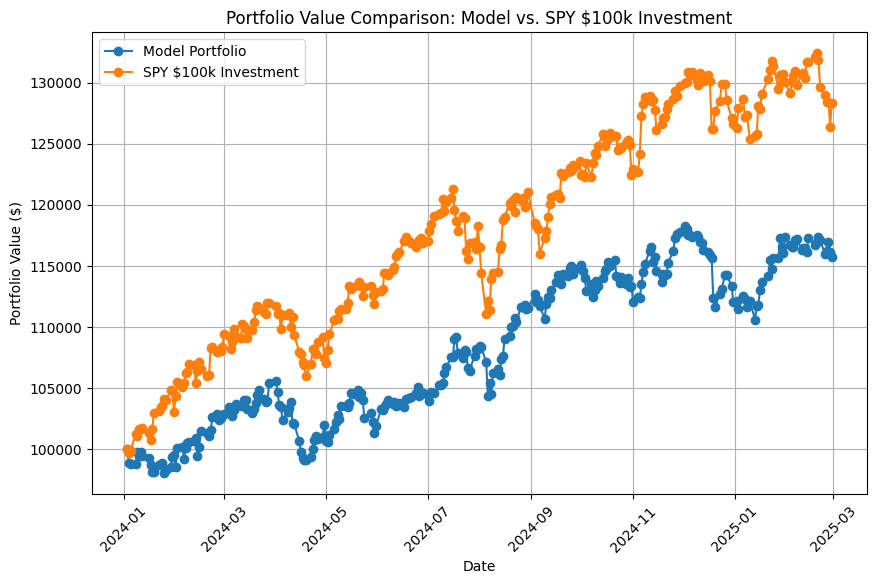

In [67]:
first_date = test_data.index[0]
first_spy_close = test_data.loc[first_date, "SPY"]

# Calculate the number of shares bought with $100k.
shares = 100000 / first_spy_close

# Compute the daily portfolio value: shares multiplied by SPY close price.
spy_portfolio_value = shares * test_data["SPY"]

# --- Plotting both performance curves ---
plt.figure(figsize=(10, 6))
# Model portfolio performance (from your DRL or portfolio optimization model)
print(date_history[0])
plt.plot(date_history, portfolio_history, marker='o', label="Model Portfolio")
# SPY performance with a one-time $100k investment
plt.plot(test_data.index, spy_portfolio_value, marker='o', label="SPY $100k Investment")

plt.title("Portfolio Value Comparison: Model vs. SPY $100k Investment")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [68]:
test_period_model_returns = (portfolio_history[-1] - portfolio_history[0]) /  portfolio_history[0] * 100
print(test_period_model_returns)
test_period_spy_returns = (spy_portfolio_value[-1] - spy_portfolio_value[0]) / spy_portfolio_value[0] * 100
print(test_period_spy_returns)

15.688218
28.37341286162463


/var/folders/nn/k590rnyx4_g52hvjx7km2s8w0000gn/T/ipykernel_42562/489560005.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test_period_spy_returns = (spy_portfolio_value[-1] - spy_portfolio_value[0]) / spy_portfolio_value[0] * 100


In [1]:
# Build a results DataFrame
results_df = pd.DataFrame({
    "Date": date_history,
    "Model_Portfolio": portfolio_history
})
print(results_df)
results_df.set_index("Date", inplace=True)

# Align SPY portfolio for same date range
spy_aligned = spy_portfolio_value.loc[results_df.index]
results_df["SPY_Portfolio"] = spy_aligned

# Calculate daily returns
results_df["Model_Returns"] = results_df["Model_Portfolio"].pct_change()
results_df["SPY_Returns"] = results_df["SPY_Portfolio"].pct_change()

# Calculate actual number of trading days
num_trading_days = results_df["Model_Returns"].dropna().shape[0]+1
print(num_trading_days)

NameError: name 'pd' is not defined

In [70]:
# Define performance metric function with risk-free adjustment
def calculate_performance_metrics(returns, name="", annual_risk_free_rate=0.03):
    daily_rf_rate = (1 + annual_risk_free_rate) ** (1 / num_trading_days) - 1
    excess_returns = returns - daily_rf_rate
    
    sharpe = (excess_returns.mean() / returns.std()) * np.sqrt(num_trading_days)
    cagr = (1 + returns.mean()) ** num_trading_days - 1
    drawdown = (returns.cumsum().expanding().max() - returns.cumsum()).max()
    
    return {
        f"{name} Sharpe Ratio": sharpe,
        f"{name} Max Drawdown": drawdown,
        f"{name} CAGR": cagr
    }

# Calculate for both model and SPY
model_metrics = calculate_performance_metrics(results_df["Model_Returns"].dropna(), "Model")
spy_metrics = calculate_performance_metrics(results_df["SPY_Returns"].dropna(), "SPY")

# Display
all_metrics = {**model_metrics, **spy_metrics}
metrics_df = pd.DataFrame.from_dict(all_metrics, orient='index', columns=["Value"])
display(metrics_df)

,Value
Model Sharpe Ratio,1.091635
Model Max Drawdown,0.066058
Model CAGR,0.164829
SPY Sharpe Ratio,1.694717
SPY Max Drawdown,0.086406
SPY CAGR,0.296744
